In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_online_retail.csv to cleaned_online_retail.csv


In [7]:
df = pd.read_csv(
    "cleaned_online_retail.csv",
    encoding="ISO-8859-1"
)

In [8]:
df = df.dropna(subset=['CustomerID'])

df = df[
    ~df['InvoiceNo']
    .astype(str)
    .str.startswith('C')
]

df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [10]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate']
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  int64         
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 27.3+ MB


In [11]:
snapshot_date = (
    df['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2011-12-10 12:50:00


In [12]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate':
        lambda x:
        (snapshot_date - x.max()).days,

    'InvoiceNo':'nunique',

    'Revenue':'sum'
})

In [13]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [14]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


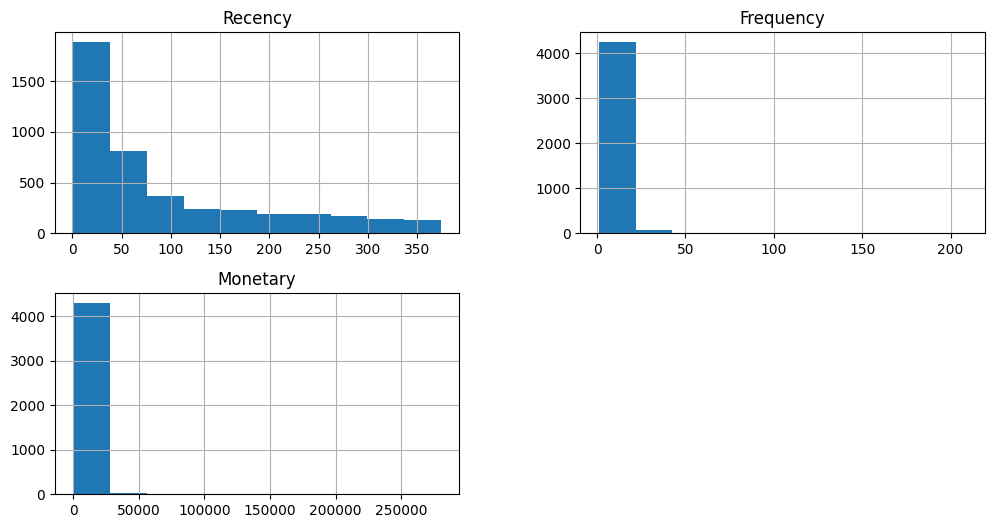

In [15]:
rfm.hist(
    figsize=(12,6)
)

plt.show()

In [17]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)
rfm_scaled.shape

(4338, 3)

In [18]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(
        kmeans.inertia_
    )

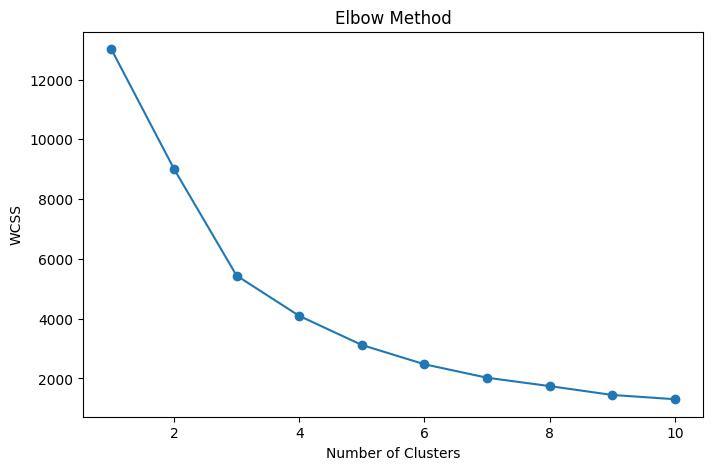

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [20]:
k = 4
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [21]:
rfm.groupby(
    'Cluster'
).mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


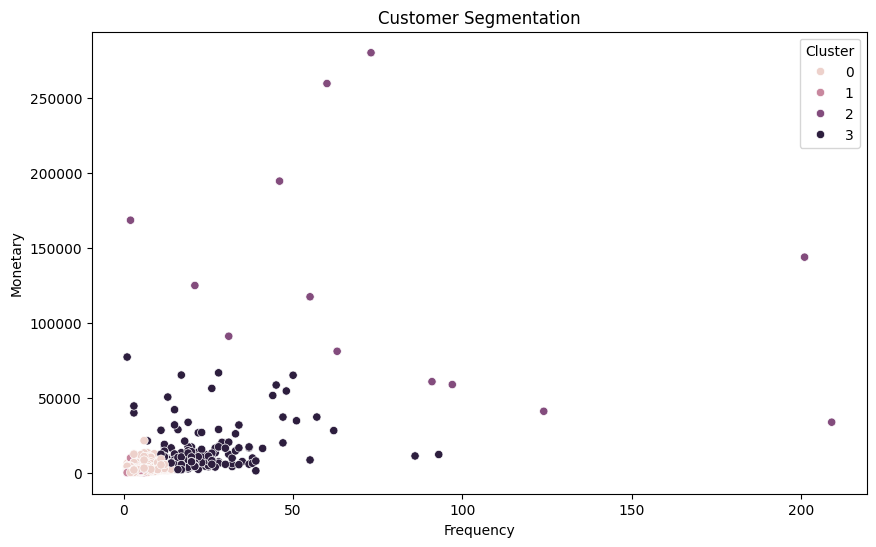

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster'
)

plt.title(
    'Customer Segmentation'
)

plt.show()

In [24]:
cluster_names = {

    0:'High Value',

    1:'Regular',

    2:'At Risk',

    3:'Premium'
}
rfm['Segment'] = (
    rfm['Cluster']
    .map(cluster_names)
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Premium
12347.0,2,7,4310.00,0,High Value
12348.0,75,4,1797.24,0,High Value
12349.0,19,1,1757.55,0,High Value
12350.0,310,1,334.40,1,Regular


In [25]:
rfm['Segment'].value_counts()

,count
Segment,
High Value,3054
Regular,1067
Premium,204
At Risk,13


In [26]:
rfm.groupby(
    'Segment'
)['Monetary'].sum()

,Monetary
Segment,
At Risk,1655398.080
High Value,4150536.513
Premium,2592654.460
Regular,512818.851


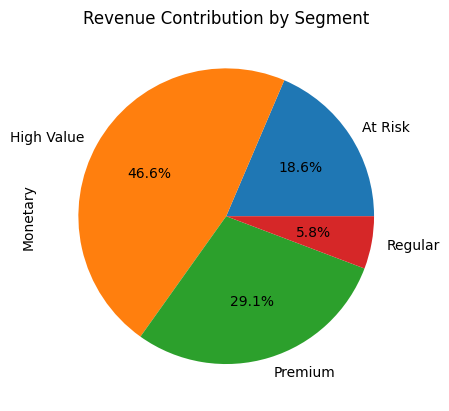

In [27]:
rfm.groupby(
    'Segment'
)['Monetary'].sum().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    "Revenue Contribution by Segment"
)

plt.show()

In [28]:
rfm.to_csv(
    "customer_segments.csv"
)

In [29]:
from google.colab import files

files.download(
    "customer_segments.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>